In [1]:
from alpaca.data import StockHistoricalDataClient
import pandas as pd

In [2]:
apikey = "PK743A6FRXXB7M91WKI8"
apisecret = "QyAD0b210eZk2HZ1VdEpPXSsu2M7qhrGkBBpyFXo"

In [3]:
clientsd = StockHistoricalDataClient(apikey, apisecret)

In [1]:
init_datapath = 'data/prices/tickers'

In [2]:
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from datetime import datetime
import os

In [6]:
snpconsts = pd.read_csv('constituents.csv')
tickers = snpconsts['Symbol'].tolist()
tickers[:5]

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN']

In [9]:
tickers = ['CHD', 'DFS', 'NTAP', 'NRG', 'ORLY', 'NVDA', 'NXPI', 'NCLH', 'TSLA']

In [10]:
from concurrent.futures import ThreadPoolExecutor, as_completed

# Initialize variables
startdt = datetime(2024, 3, 1, 0, 0)
strstartdt = str(startdt)[:10]
tfunit = TimeFrame.Minute
tfvalue = tfunit.amount_value
unit = tfunit.unit.split(':')[0]
init_datapath = init_datapath
os.makedirs(init_datapath, exist_ok=True)

failed_ticks = []
total_data = pd.DataFrame()

def fetch_and_store_data(ticker):
    try:
        request = StockBarsRequest(symbol_or_symbols=ticker, start=startdt, timeframe=tfunit)
        tickerdata = clientsd.get_stock_bars(request).df
        filename = f"{ticker}_{strstartdt}_{tfvalue}{unit}_interval.parquet"
        tickerdata.to_parquet(os.path.join(init_datapath, filename))
        print(f"Successfully downloaded data for {ticker}")
        return tickerdata
    except Exception as e:
        print(f"Failed download for ticker = {ticker}, Error: {e}")
        return ticker, None  # Return ticker to handle failures

# Function to handle multithreading
def fetch_all_data_multithreaded(tickers, max_threads=5):
    global total_data
    with ThreadPoolExecutor(max_threads) as executor:
        future_to_ticker = {executor.submit(fetch_and_store_data, ticker): ticker for ticker in tickers}
        for future in as_completed(future_to_ticker):
            ticker = future_to_ticker[future]
            try:
                result = future.result()
                if result is not None and not isinstance(result, tuple):
                    total_data = pd.concat([total_data, result])
                elif isinstance(result, tuple):
                    failed_ticks.append(result[0])
            except Exception as e:
                print(f"Exception occurred for {ticker}: {e}")
                time.sleep(1)
                failed_ticks.append(ticker)

# Fetch data with multithreading
fetch_all_data_multithreaded(tickers)

Successfully downloaded data for ORLY
Successfully downloaded data for DFS
Successfully downloaded data for CHD
Successfully downloaded data for NRG
Successfully downloaded data for NTAP
Successfully downloaded data for NXPI
Successfully downloaded data for NCLH
Successfully downloaded data for NVDA
Successfully downloaded data for TSLA


In [8]:
failed_ticks

['CHD', 'DFS', 'NTAP', 'NRG', 'ORLY', 'NVDA', 'NXPI', 'NCLH', 'TSLA']

In [ ]:
# startdt = datetime(2024,3, 1, 0,0)
# strstartdt = str(startdt)[:10]
# tfunit = TimeFrame.Minute
# # tf = TimeFrame(1, 'Min')
# tfvalue = tfunit.amount_value
# unit = tfunit.unit.split(':')[0]

# failed_ticks = []
# total_data = pd.DataFrame()
# count = 0
# for ticker in tickers:
#     request = StockBarsRequest(symbol_or_symbols=ticker, start = startdt, timeframe = tfunit)
#     count += 1
#     tickerdata = clientsd.get_stock_bars(request).df
#     filename = f'{ticker}_{strstartdt}_{tfvalue}{unit}_interval.parquet'
#     tickerdata.to_parquet(os.path.join(init_datapath, filename))
    
#     try:
#         tickerdata = clientsd.get_stock_bars(request).df
#         filename = f'{ticker}_{strstartdt}_{tfvalue}{unit}_interval.parquet'
#         tickerdata.to_parquet(os.path.join(init_datapath, filename))
#         total_data = pd.concat([total_data, tickerdata])
#         if count % 5 == 0:
#             print("Downloaded data for {count} tickers. Last ticker = {ticker}")
#     except:
#         print(f"Failed download for ticker = {ticker}")
#         failed_ticks.append(ticker)

In [12]:
eqdata = pd.DataFrame()
count = 0
for file in os.listdir(init_datapath):
    tmpdata = pd.read_parquet(os.path.join(init_datapath, file))
    eqdata = pd.concat([eqdata, tmpdata])
    count +=1 
    if count % 10 == 0:
        print(f"Files concatenated = {count}")

Files concatenated = 10
Files concatenated = 20
Files concatenated = 30
Files concatenated = 40
Files concatenated = 50
Files concatenated = 60
Files concatenated = 70
Files concatenated = 80
Files concatenated = 90
Files concatenated = 100
Files concatenated = 110
Files concatenated = 120
Files concatenated = 130
Files concatenated = 140
Files concatenated = 150
Files concatenated = 160
Files concatenated = 170
Files concatenated = 180
Files concatenated = 190
Files concatenated = 200
Files concatenated = 210
Files concatenated = 220
Files concatenated = 230
Files concatenated = 240
Files concatenated = 250
Files concatenated = 260
Files concatenated = 270
Files concatenated = 280
Files concatenated = 290
Files concatenated = 300
Files concatenated = 310
Files concatenated = 320
Files concatenated = 330
Files concatenated = 340
Files concatenated = 350
Files concatenated = 360
Files concatenated = 370
Files concatenated = 380
Files concatenated = 390
Files concatenated = 400
Files con

In [13]:
eqdata.shape

(35742531, 7)

In [15]:
eqdata = eqdata.reset_index()

In [ ]:
# eqdata.to_parquet(os.path.join(init_datapath, 'allequityconcatdata.parquet'))

In [1]:
init_datapath = 'data/prices/tickers'
import pandas as pd
import os
eqdata = pd.read_parquet(os.path.join(init_datapath, 'allequityconcatdata.parquet'))

In [3]:
eqdata.shape

(35742531, 9)

In [4]:
eqdata = eqdata.loc[eqdata.timestamp > '2024-05-01 00:03:00+00:00', ['symbol', 'timestamp', 'close']]
eqdata.shape

(27773638, 3)

In [ ]:
features1 = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 70, 80, 90, 100, 110, 120, 140, 160, 180]
features2 = features1 + [i for i in range(210, 3600, 120)]
features = features2 + [i for i in range(3600, 30000, 3600)]
def generate_features(df):
    for i in features:
        df['momentum_'+str(i)+'mins'] = (df['close']/(df['close'].shift(i))) - 1
    return df


def generate_features_by_asset(df2):
    groups = df2.groupby('symbol')
    final_df = pd.DataFrame()
    count = 0
    for i, group in groups:
        count += 1
        if count %5 == 0:
            print(count)
        tmpdf = generate_features(group)
        final_df = pd.concat([final_df, tmpdf])
    return final_df    

eqdata = eqdata.groupby('symbol').apply(generate_features)
print(f"eq data shape = {eqdata.shape}")

eqdata.tail(5)

In [ ]:
histdata_snp = eqdata.copy()
del eqdata

open  ...  momentum_39600mins
symbol timestamp                          ...                    
SPY    2024-01-02 09:00:00+00:00  476.25  ...                 NaN
       2024-01-02 09:01:00+00:00  476.34  ...                 NaN
       2024-01-02 09:02:00+00:00  476.29  ...                 NaN
       2024-01-02 09:03:00+00:00  476.27  ...                 NaN
       2024-01-02 09:05:00+00:00  476.20  ...                 NaN
       2024-01-02 09:06:00+00:00  476.18  ...                 NaN
       2024-01-02 09:07:00+00:00  476.21  ...                 NaN
       2024-01-02 09:08:00+00:00  476.19  ...                 NaN
       2024-01-02 09:10:00+00:00  476.13  ...                 NaN
       2024-01-02 09:11:00+00:00  476.03  ...                 NaN

[10 rows x 72 columns]

In [296]:
print(f'histdata_snp shape = {histdata_snp.shape}')

histdata_snp shape = (181283, 80)


In [297]:
import os
os.getcwd()

'c:\\Users\\shaya\\OneDrive\\Documents\\Python Project\\TradingProject'

In [298]:
histdata_snp.to_parquet('histdata_snp.parquet')

### Model Training 

In [ ]:
#for skipping preprocessing steps by saving data to disk

if os.path.exists('histdata_snp.parquet'):
    histdata_snp  = pd.read_parquet('histdata_snp.parquet')


In [381]:
histdata_snp =histdata_snp.reset_index()

In [382]:
# histdata_snp[fwdret_col] = histdata_snp['momentum_5mins'].shift(-5)
# std_dev = np.std(histdata_snp[fwdret_col].dropna())
# histdata_snp[fwdret_col] = zscore(histdata_snp[fwdret_col])
# histdata_snp[fwdret_col_bin] = np.where(histdata_snp[fwdret_col] > 0 + 0.25*std_dev , 1, 0)
# histdata_snp[fwdret_col]

In [383]:
#hyper parameters
fwd_mins = 5
#number securities = 1
pos_margin_bin = 0.2

from scipy.stats import zscore
fwdret_col = 'fwd_'+str(fwd_mins) + 'mins'
fwdret_col_bin = fwdret_col + '_bin'
histdata_snp[fwdret_col] = (histdata_snp['close'].shift(-fwd_mins)/histdata_snp['close']) - 1
# histdata_snp[fwdret_col] = histdata_snp['momentum_5mins'].shift(-5)
std_dev = np.std(histdata_snp[fwdret_col].dropna())
histdata_snp[fwdret_col_bin] = np.where(histdata_snp[fwdret_col] > 0 + pos_margin_bin*std_dev , 1, 0)
histdata_snp.loc[(histdata_snp[fwdret_col_bin] == 0) & (histdata_snp[fwdret_col] < 0 - pos_margin_bin*std_dev), fwdret_col_bin] = -1
# histdata_snp[fwdret_col]
histdata_snp.head(7)

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap,momentum_1mins,momentum_2mins,momentum_3mins,momentum_4mins,momentum_5mins,momentum_10mins,momentum_15mins,momentum_20mins,momentum_25mins,momentum_30mins,momentum_35mins,momentum_40mins,momentum_45mins,momentum_50mins,momentum_55mins,momentum_60mins,momentum_70mins,momentum_80mins,momentum_90mins,momentum_100mins,momentum_110mins,momentum_120mins,momentum_140mins,momentum_160mins,momentum_180mins,momentum_210mins,momentum_330mins,momentum_450mins,momentum_570mins,momentum_690mins,momentum_810mins,...,momentum_1410mins,momentum_1530mins,momentum_1650mins,momentum_1770mins,momentum_1890mins,momentum_2010mins,momentum_2130mins,momentum_2250mins,momentum_2370mins,momentum_2490mins,momentum_2610mins,momentum_2730mins,momentum_2850mins,momentum_2970mins,momentum_3090mins,momentum_3210mins,momentum_3330mins,momentum_3450mins,momentum_3570mins,momentum_3600mins,momentum_7200mins,momentum_10800mins,momentum_14400mins,momentum_18000mins,momentum_21600mins,momentum_25200mins,momentum_28800mins,momentum_32400mins,momentum_36000mins,momentum_39600mins,momentum_43200mins,momentum_46800mins,momentum_50400mins,momentum_54000mins,momentum_57600mins,momentum_61200mins,momentum_64800mins,momentum_68400mins,fwd_5mins,fwd_5mins_bin
0,SPY,2024-01-02 09:00:00+00:00,476.25,476.36,476.00,476.31,20460.0,84.0,476.301058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000273,-1
1,SPY,2024-01-02 09:01:00+00:00,476.34,476.34,476.29,476.29,6369.0,16.0,476.320154,-0.000042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000315,-1
2,SPY,2024-01-02 09:02:00+00:00,476.29,476.29,476.28,476.28,6152.0,10.0,476.280164,-0.000021,-0.000063,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000189,-1
3,SPY,2024-01-02 09:03:00+00:00,476.27,476.27,476.27,476.27,369.0,10.0,476.270000,-0.000021,-0.000042,-0.000084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000315,-1
4,SPY,2024-01-02 09:05:00+00:00,476.20,476.20,476.19,476.19,547.0,8.0,476.192404,-0.000168,-0.000189,-0.000210,-0.000252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000336,-1
5,SPY,2024-01-02 09:06:00+00:00,476.18,476.18,476.18,476.18,230.0,13.0,476.180000,-0.000021,-0.000189,-0.000210,-0.000231,-0.000273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000378,-1
6,SPY,2024-01-02 09:07:00+00:00,476.21,476.21,476.14,476.14,5624.0,18.0,476.146364,-0.000084,-0.000105,-0.000273,-0.000294,-0.000315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [384]:
histdata_snp = histdata_snp.set_index('timestamp')

In [385]:
print(histdata_snp.index.min(), histdata_snp.index.max())
histdata_snp.describe()

2024-01-02 09:00:00+00:00 2024-11-29 21:59:00+00:00


,open,high,low,close,volume,trade_count,vwap,momentum_1mins,momentum_2mins,momentum_3mins,momentum_4mins,momentum_5mins,momentum_10mins,momentum_15mins,momentum_20mins,momentum_25mins,momentum_30mins,momentum_35mins,momentum_40mins,momentum_45mins,momentum_50mins,momentum_55mins,momentum_60mins,momentum_70mins,momentum_80mins,momentum_90mins,momentum_100mins,momentum_110mins,momentum_120mins,momentum_140mins,momentum_160mins,momentum_180mins,momentum_210mins,momentum_330mins,momentum_450mins,momentum_570mins,momentum_690mins,momentum_810mins,momentum_930mins,momentum_1050mins,...,momentum_1410mins,momentum_1530mins,momentum_1650mins,momentum_1770mins,momentum_1890mins,momentum_2010mins,momentum_2130mins,momentum_2250mins,momentum_2370mins,momentum_2490mins,momentum_2610mins,momentum_2730mins,momentum_2850mins,momentum_2970mins,momentum_3090mins,momentum_3210mins,momentum_3330mins,momentum_3450mins,momentum_3570mins,momentum_3600mins,momentum_7200mins,momentum_10800mins,momentum_14400mins,momentum_18000mins,momentum_21600mins,momentum_25200mins,momentum_28800mins,momentum_32400mins,momentum_36000mins,momentum_39600mins,momentum_43200mins,momentum_46800mins,momentum_50400mins,momentum_54000mins,momentum_57600mins,momentum_61200mins,momentum_64800mins,momentum_68400mins,fwd_5mins,fwd_5mins_bin
count,181283.000000,181283.000000,181283.000000,181283.000000,1.812830e+05,181283.000000,181283.000000,181282.000000,181281.000000,181280.000000,181279.000000,181278.000000,181273.000000,181268.000000,181263.000000,181258.000000,181253.000000,181248.000000,181243.000000,181238.000000,181233.000000,181228.000000,181223.000000,181213.000000,181203.000000,181193.000000,181183.000000,181173.000000,181163.000000,181143.000000,181123.000000,181103.000000,181073.000000,180953.000000,180833.000000,180713.000000,180593.000000,180473.000000,180353.000000,180233.000000,...,179873.000000,179753.000000,179633.000000,179513.000000,179393.000000,179273.000000,179153.000000,179033.000000,178913.000000,178793.000000,178673.000000,178553.000000,178433.000000,178313.000000,178193.000000,178073.000000,177953.000000,177833.000000,177713.000000,177683.000000,174083.000000,170483.000000,166883.000000,163283.000000,159683.000000,156083.000000,152483.000000,148883.000000,145283.000000,141683.000000,138083.000000,134483.000000,130883.000000,127283.000000,123683.000000,120083.000000,116483.000000,112883.000000,181278.000000,181283.000000
mean,535.749075,535.819571,535.675796,535.749077,7.389687e+04,604.176619,535.748332,0.000001,0.000003,0.000004,0.000005,0.000007,0.000013,0.000020,0.000027,0.000034,0.000040,0.000047,0.000054,0.000061,0.000067,0.000074,0.000081,0.000094,0.000108,0.000122,0.000135,0.000149,0.000163,0.000191,0.000218,0.000246,0.000288,0.000454,0.000618,0.000782,0.000947,0.001109,0.001273,0.001439,...,0.001948,0.002120,0.002290,0.002460,0.002630,0.002799,0.002966,0.003136,0.003306,0.003477,0.003651,0.003826,0.003998,0.004170,0.004342,0.004512,0.004684,0.004855,0.005021,0.005063,0.009768,0.014816,0.019374,0.023498,0.027746,0.032122,0.036486,0.040346,0.044252,0.048097,0.051905,0.054642,0.057780,0.061764,0.066377,0.071172,0.074720,0.079237,0.000007,0.025904
std,33.727691,33.727599,33.726981,33.727664,2.138496e+05,911.451838,33.727316,0.000297,0.000409,0.000493,0.000565,0.000630,0.000876,0.001063,0.001225,0.001366,0.001497,0.001619,0.001732,0.001838,0.001941,0.002040,0.002137,0.002316,0.002484,0.002636,0.002778,0.002914,0.003043,0.003287,0.003516,0.003727,0.004015,0.005044,0.005879,0.006601,0.007251,0.007864,0.008442,0.008985,...,0.010431,0.010856,0.011262,0.011652,0.012019,0.012343,0.012656,0.012962,0.013255,0.013562,0.013890,0.014226,0.014569,0.014905,0.015230,0.015553,0.015858,0.016173,0.016479,0.016555,0.022581,0.025715,0.026924,0.028190,0.030370,0.031494,0.032670,0.033252,0.034343,0.033796,0.032995,0.028977,0.023953,0.021995,0.021439,0.024946,0.024834,0.025070,0.000630,0.837421
min,464.750000,465.000000,464.610000,464.710000,1.000000e+02,1.000000,464.8

In [386]:
histdata_snp[fwdret_col_bin].describe([0.05, 0.1, 0.40, 0.45, 0.55, 0.6, 0.8, 0.9, 0.95])

count    181283.000000
mean          0.025904
std           0.837421
min          -1.000000
5%           -1.000000
10%          -1.000000
40%           0.000000
45%           0.000000
50%           0.000000
55%           0.000000
60%           0.000000
80%           1.000000
90%           1.000000
95%           1.000000
max           1.000000
Name: fwd_5mins_bin, dtype: float64

In [387]:
histdata_snp = histdata_snp.dropna()
print(histdata_snp.index.min(), histdata_snp.index.max())
histdata_snp.describe()

2024-05-06 12:09:00+00:00 2024-11-29 21:53:00+00:00


,open,high,low,close,volume,trade_count,vwap,momentum_1mins,momentum_2mins,momentum_3mins,momentum_4mins,momentum_5mins,momentum_10mins,momentum_15mins,momentum_20mins,momentum_25mins,momentum_30mins,momentum_35mins,momentum_40mins,momentum_45mins,momentum_50mins,momentum_55mins,momentum_60mins,momentum_70mins,momentum_80mins,momentum_90mins,momentum_100mins,momentum_110mins,momentum_120mins,momentum_140mins,momentum_160mins,momentum_180mins,momentum_210mins,momentum_330mins,momentum_450mins,momentum_570mins,momentum_690mins,momentum_810mins,momentum_930mins,momentum_1050mins,...,momentum_1410mins,momentum_1530mins,momentum_1650mins,momentum_1770mins,momentum_1890mins,momentum_2010mins,momentum_2130mins,momentum_2250mins,momentum_2370mins,momentum_2490mins,momentum_2610mins,momentum_2730mins,momentum_2850mins,momentum_2970mins,momentum_3090mins,momentum_3210mins,momentum_3330mins,momentum_3450mins,momentum_3570mins,momentum_3600mins,momentum_7200mins,momentum_10800mins,momentum_14400mins,momentum_18000mins,momentum_21600mins,momentum_25200mins,momentum_28800mins,momentum_32400mins,momentum_36000mins,momentum_39600mins,momentum_43200mins,momentum_46800mins,momentum_50400mins,momentum_54000mins,momentum_57600mins,momentum_61200mins,momentum_64800mins,momentum_68400mins,fwd_5mins,fwd_5mins_bin
count,112878.000000,112878.000000,112878.000000,112878.000000,1.128780e+05,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,...,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000,112878.000000
mean,556.801344,556.874285,556.725076,556.801449,6.221769e+04,544.062669,556.800262,0.000001,0.000003,0.000004,0.000006,0.000007,0.000015,0.000022,0.000029,0.000037,0.000044,0.000051,0.000059,0.000066,0.000073,0.000081,0.000088,0.000103,0.000118,0.000132,0.000147,0.000162,0.000176,0.000206,0.000236,0.000265,0.000310,0.000488,0.000662,0.000839,0.001016,0.001192,0.001374,0.001558,...,0.002131,0.002329,0.002520,0.002712,0.002907,0.003100,0.003288,0.003483,0.003676,0.003871,0.004067,0.004266,0.004460,0.004645,0.004826,0.005000,0.005174,0.005345,0.005514,0.005556,0.010577,0.016293,0.020923,0.024353,0.027938,0.031636,0.035630,0.039062,0.042784,0.046679,0.050635,0.053734,0.057341,0.061929,0.066634,0.071169,0.074645,0.079235,0.000007,0.027959
std,22.523130,22.516962,22.528920,22.523110,1.915647e+05,831.971355,22.523231,0.000302,0.000421,0.000510,0.000585,0.000652,0.000907,0.001098,0.001264,0.001408,0.001543,0.001669,0.001783,0.001891,0.001996,0.002096,0.002196,0.002385,0.002561,0.002720,0.002869,0.003014,0.003150,0.003412,0.003655,0.003880,0.004183,0.005231,0.006079,0.006810,0.007486,0.008115,0.008708,0.009273,...,0.010829,0.011320,0.011820,0.012315,0.012789,0.013192,0.013594,0.014001,0.014413,0.014871,0.015337,0.015790,0.016217,0.016623,0.017007,0.017384,0.017740,0.018086,0.018414,0.018495,0.024774,0.026553,0.026173,0.026616,0.028917,0.030257,0.030958,0.031798,0.033033,0.032617,0.031626,0.027636,0.023404,0.022351,0.022347,0.025580,0.025155,0.025069,0.000652,0.838595
min,508.430000,508.940000,507.830000,508.460000,1.000000e+02,1.000000,508.4

In [388]:
#create datasets

test_ts = '2024-11-01 00:00:00+00:00'

X_train = histdata_snp.loc[:test_ts, histdata_snp.columns.str.contains('momentum')]
y_train = histdata_snp.loc[:test_ts, fwdret_col_bin]

# X_train_hyp = histdata_snp.loc['2024-10-15 00:00:00+00:00' :'2024-11-15 00:00:00+00:00', histdata_snp.columns.str.contains('momentum')]
# y_train_hyp = histdata_snp.loc['2024-10-15 00:00:00+00:00' :'2024-11-15 00:00:00+00:00', fwdret_col_bin]


X_test = histdata_snp.loc[test_ts:, histdata_snp.columns.str.contains('momentum')]
y_test = histdata_snp.loc[test_ts:, fwdret_col_bin]

In [389]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

# # Define the model
# rf = RandomForestClassifier(random_state=42)

# # Define the parameter grid
# param_grid = {
#     'n_estimators': [50, 100],
#     'max_depth': [10, 20, 30],
#     'min_samples_split': [4, 8, 14],
#     'min_samples_leaf': [3, 5, 10],
#     'max_features': ['sqrt', 'log2'],
#     'bootstrap': [True, False]
# }

# # Perform Grid Search
# grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
#                            cv=3, scoring='accuracy', verbose=2, n_jobs=-1)

# grid_search.fit(X_train_hyp, y_train_hyp)

# # Best parameters
# print("Best Parameters:", grid_search.best_params_)

# # Best estimator
# best_model = grid_search.best_estimator_

In [390]:
# best_params = grid_search.best_params_
# best_params['n_jobs'] = -1
# best_params

In [391]:
best_params = {
    'n_estimators': 50,
    'max_depth': 10,
    'min_samples_split': 8,
    'min_samples_leaf': 4,
    'max_features': 'sqrt',
    'bootstrap': True,
    'n_jobs' : -1
}

In [392]:
clf = RandomForestClassifier(**best_params)
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=8,
                       n_estimators=50, n_jobs=-1)

In [393]:
y_pred = clf.predict(X_test)
histdata_snp.loc[test_ts:, fwdret_col_bin+'_pred'] = y_pred
probs = clf.predict_proba(X_test)
predicted_class_prob = np.max(probs, axis=1)
histdata_snp.loc[test_ts:, fwdret_col_bin+'_predprob'] = predicted_class_prob
histdata_snp['pred_match'] = np.nan
histdata_snp['pred_match'] = (histdata_snp[fwdret_col_bin+'_pred'] == histdata_snp[fwdret_col_bin]).astype(int)

In [394]:
# tst =histdata_snp.loc[test_ts:,:]
# tst.reset_index(inplace = True)

In [395]:
histdata_snp.reset_index(inplace = True)
tst =histdata_snp.loc[histdata_snp.timestamp >= test_ts, :]
tst.reset_index(inplace = True)
tst = tst.loc[tst[fwdret_col_bin+'_pred'] != 0]
tst['day'] = pd.to_datetime(tst.timestamp).dt.strftime('%Y-%m-%d')
tst.sort_values(['day', fwdret_col_bin+'_pred', fwdret_col_bin+'_predprob'], ascending = [True, True, False], inplace = True)
tst_selected = tst.groupby(['day', fwdret_col_bin+'_pred'])[fwdret_col_bin+'_predprob'].head(15)


In [396]:
tst.loc[tst.index.isin(tst_selected.index), 'selected'] = 1

In [ ]:
tst.loc[tst.selected == 1, 'rets'] = tst.loc[tst.selected == 1, fwdret_col_bin+'_pred']*tst.loc[tst.selected == 1, fwdret_col]
rets = tst.groupby('day')['rets'].sum()
rets

day
2024-11-01   -0.001360
2024-11-04   -0.003148
2024-11-05    0.002174
2024-11-06    0.012659
2024-11-07    0.001506
2024-11-08    0.004234
2024-11-11    0.002955
2024-11-12    0.007171
2024-11-13    0.005999
2024-11-14    0.006601
2024-11-15    0.008441
2024-11-16   -0.000189
2024-11-18    0.009019
2024-11-19   -0.004467
2024-11-20   -0.004522
2024-11-21   -0.015123
2024-11-22    0.010312
2024-11-25    0.010511
2024-11-26    0.003852
2024-11-27    0.007709
2024-11-29    0.002159
Name: rets, dtype: float64

In [398]:
rets = tst.groupby('day')['rets'].sum()
aum = (1+rets).cumprod()

In [399]:
importances = clf.feature_importances_
feature_names = histdata_snp.columns[histdata_snp.columns.str.contains('momentum')]

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

               Feature  Importance
1       momentum_2mins    0.032709
2       momentum_3mins    0.032532
5      momentum_10mins    0.031038
4       momentum_5mins    0.030160
12     momentum_45mins    0.025837
55   momentum_7200mins    0.022703
0       momentum_1mins    0.021847
3       momentum_4mins    0.021237
13     momentum_50mins    0.021170
11     momentum_40mins    0.019972
6      momentum_15mins    0.019615
9      momentum_30mins    0.019460
10     momentum_35mins    0.018242
7      momentum_20mins    0.018042
56  momentum_10800mins    0.017627
8      momentum_25mins    0.016899
19    momentum_100mins    0.016733
57  momentum_14400mins    0.016437
16     momentum_70mins    0.016380
71  momentum_64800mins    0.016278


In [400]:
import ffn
%matplotlib inline

In [401]:
aum = (1+rets).cumprod()
aum.index = pd.to_datetime(aum.index)
# print(aum)
stats = aum.calc_stats()
stats.display()

Stats for rets from 2024-11-01 00:00:00 - 2024-11-29 00:00:00
Annual risk-free rate considered: 0.00%
Summary:
Total Return      Sharpe  CAGR     Max Drawdown
--------------  --------  -------  --------------
6.96%               8.19  140.68%  -2.40%

Annualized Returns:
mtd    3m    6m    ytd    1y    3y    5y    10y    incep.
-----  ----  ----  -----  ----  ----  ----  -----  --------
6.96%  -     -     6.96%  -     -     -     -      140.68%

Periodic:
        daily    monthly    yearly
------  -------  ---------  --------
sharpe  8.19     -          -
mean    85.50%   -          -
vol     10.44%   -          -
skew    -1.17    -          -
kurt    1.94     -          -
best    1.27%    -          -
worst   -1.51%   -          -

Drawdowns:
max     avg       # days
------  ------  --------
-2.40%  -0.91%      3.67

Misc:
---------------  -
avg. up month    -
avg. down month  -
up year %        -
12m up %         -
---------------  -


<Axes: xlabel='day'>

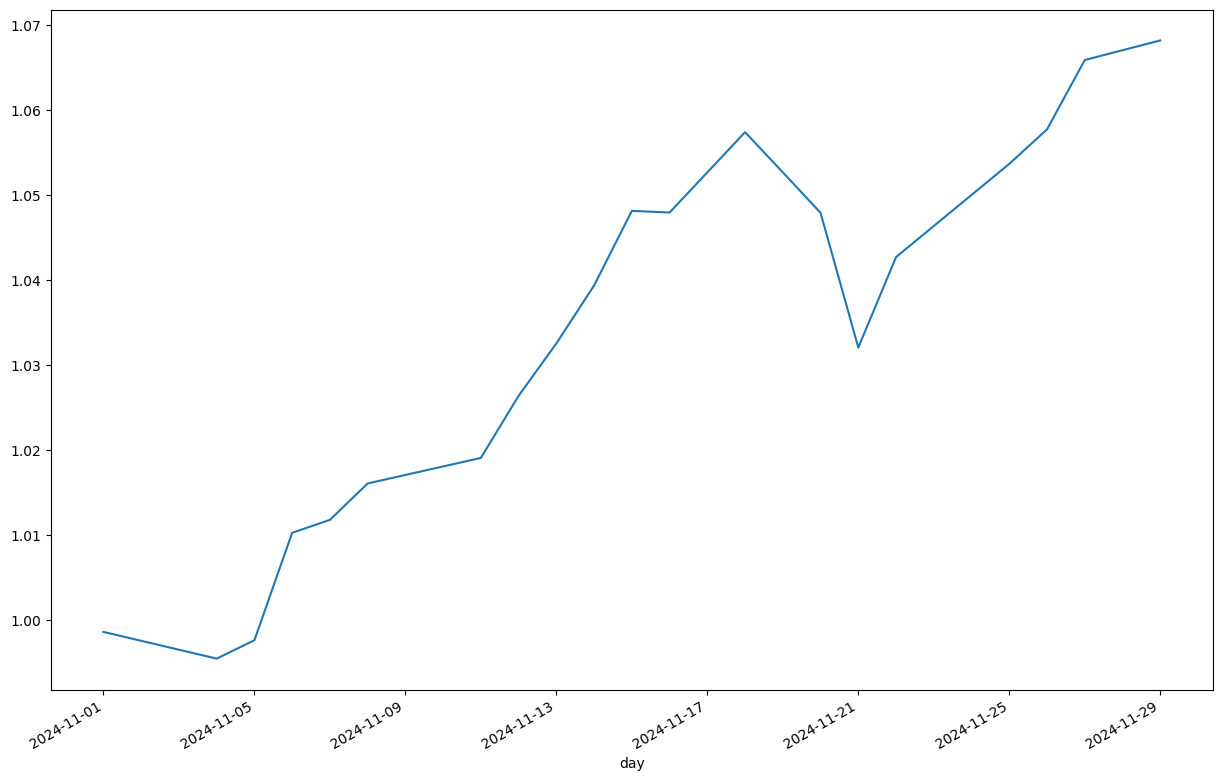

In [402]:
aum.plot(figsize = (15,10))